## Setup: Install `opendatasets` and Download Data

In [5]:
# Install opendatasets library if not already installed
!pip install opendatasets

import opendatasets as od
import pandas as pd

### Download the FIFA World Cup dataset from Kaggle

This step requires Kaggle credentials (username and API key). You can generate an API token from your Kaggle account settings.

In [8]:
# Replace 'your_kaggle_username' and 'your_kaggle_key' with your actual Kaggle credentials
# Alternatively, you can use the Colab secrets manager for these credentials.

# If using Colab Secrets, uncomment the following lines and ensure 'KAGGLE_USERNAME' and 'KAGGLE_KEY' are set in your secrets.
import os
from google.colab import userdata # Import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

od.download("https://www.kaggle.com/datasets/iamsouravbanerjee/fifa-football-world-cup-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: errolcooper
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/iamsouravbanerjee/fifa-football-world-cup-dataset


100%|██████████| 13.0k/13.0k [00:00<00:00, 19.1MB/s]

The dataset should now be downloaded to the `/content/fifa-football-world-cup-dataset/` directory.

Now, let's load the `WorldCups.csv` and `WorldCupMatches.csv` files into pandas DataFrames.

In [12]:
import pandas as pd
import os

try:
    dataset_path = '/content/fifa-football-world-cup-dataset/'

    # Print current working directory and list files in the dataset directory for debugging
    print(f"Current working directory: {os.getcwd()}")
    all_files_in_dir = os.listdir(dataset_path)
    print(f"Contents of {dataset_path}: {all_files_in_dir}")

    world_cups_df = None
    world_cup_matches_df = None # This will store the concatenated team stats with year
    combined_df = None # This will store the final merged DataFrame

    # --- Load World Cup Summary DataFrame ---
    summary_file_path = os.path.join(dataset_path, 'FIFA - World Cup Summary.csv')
    if not os.path.exists(summary_file_path):
        print(f"Error: Summary CSV file NOT found at {summary_file_path}")
    else:
        print(f"Summary CSV file found at {summary_file_path}. Attempting to load...")
        world_cups_df = pd.read_csv(summary_file_path)
        print("World Cups Summary DataFrame (first 5 rows):")
        display(world_cups_df.head())

    # --- Load World Cup Matches Data from individual year files and add 'YEAR' column ---
    match_files_list = [f for f in all_files_in_dir if f.startswith('FIFA - ') and f.endswith('.csv') and f != 'FIFA - World Cup Summary.csv']

    if not match_files_list:
        print("Error: No individual match CSV files found (e.g., 'FIFA - 19XX.csv').")
    else:
        print(f"Found {len(match_files_list)} individual match files. Attempting to load and concatenate...")
        all_matches_dfs = []
        for f_name in match_files_list:
            file_path = os.path.join(dataset_path, f_name)
            try:
                df = pd.read_csv(file_path)
                # Extract year from filename (e.g., 'FIFA - 1930.csv' -> 1930)
                year_str = f_name.replace('FIFA - ', '').replace('.csv', '').strip()
                try:
                    year = int(year_str)
                    df['YEAR'] = year # Add 'YEAR' column for merging
                    all_matches_dfs.append(df)
                except ValueError:
                    print(f"Warning: Could not parse year from filename {f_name}. Skipping.")
            except Exception as e:
                print(f"Warning: Could not load {f_name} due to error: {e}")

        if all_matches_dfs:
            world_cup_matches_df = pd.concat(all_matches_dfs, ignore_index=True)
            print("\nWorld Cup Matches DataFrame (first 5 rows after concatenation and year addition):")
            display(world_cup_matches_df.head())
        else:
            print("No match data could be loaded from individual files.")

    # --- Merge the two DataFrames ---
    if world_cups_df is not None and world_cup_matches_df is not None:
        print("\nMerging World Cup Summary and Matches dataframes...")
        # Ensure 'YEAR' column is of the same type for merging
        world_cups_df['YEAR'] = world_cups_df['YEAR'].astype(int)
        world_cup_matches_df['YEAR'] = world_cup_matches_df['YEAR'].astype(int)

        combined_df = pd.merge(world_cup_matches_df, world_cups_df, on='YEAR', how='left')
        print("Combined DataFrame (first 5 rows):")
        display(combined_df.head())
        print(f"Combined DataFrame shape: {combined_df.shape}")
    else:
        print("Cannot merge dataframes because one or both were not loaded successfully.")

except FileNotFoundError as e:
    print(f"A FileNotFoundError occurred: {e}. Please ensure the dataset is downloaded correctly and the paths are accurate.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Current working directory: /content
Contents of /content/fifa-football-world-cup-dataset/: ['FIFA - 2018.csv', 'FIFA - World Cup Summary.csv', 'FIFA - 2002.csv', 'FIFA - 1990.csv', 'FIFA - 1998.csv', 'FIFA - 1930.csv', 'FIFA - 1962.csv', 'FIFA - 2022.csv', 'FIFA - 1950.csv', 'FIFA - 2014.csv', 'FIFA - 1958.csv', 'FIFA - 1954.csv', 'FIFA - 1994.csv', 'FIFA - 1982.csv', 'FIFA - 1970.csv', 'FIFA - 2006.csv', 'FIFA - 1986.csv', 'FIFA - 1938.csv', 'FIFA - 1966.csv', 'FIFA - 1974.csv', 'FIFA - 1978.csv', 'FIFA - 2010.csv', 'FIFA - 1934.csv']
Summary CSV file found at /content/fifa-football-world-cup-dataset/FIFA - World Cup Summary.csv. Attempting to load...
World Cups Summary DataFrame (first 5 rows):


,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1930,Uruguay,Uruguay,Argentina,United States,13,16,70,3.6
1,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
2,1938,France,Italy,Hungary,Brazil,15,18,84,4.7
3,1950,Brazil,Uruguay,Brazil,Sweden,13,22,88,4.0
4,1954,Switzerland,West Germany,Hungary,Austria,16,26,140,5.4


Found 22 individual match files. Attempting to load and concatenate...

World Cup Matches DataFrame (first 5 rows after concatenation and year addition):


,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,YEAR
0,1,France,7,6,1,0,14,6,8,19,2018
1,2,Croatia,7,4,2,1,14,9,5,14,2018
2,3,Belgium,7,6,0,1,16,6,10,18,2018
3,4,England,7,3,1,3,12,8,4,10,2018
4,5,Uruguay,5,4,0,1,7,3,4,12,2018



Merging World Cup Summary and Matches dataframes...
Combined DataFrame (first 5 rows):


,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1,France,7,6,1,0,14,6,8,19,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
1,2,Croatia,7,4,2,1,14,9,5,14,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
2,3,Belgium,7,6,0,1,16,6,10,18,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
3,4,England,7,3,1,3,12,8,4,10,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
4,5,Uruguay,5,4,0,1,7,3,4,12,2018,Russia,France,Croatia,Belgium,32,64,169,2.6


Combined DataFrame shape: (489, 19)


In [13]:
print("Combined DataFrame Info:")
combined_df.info()

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Position            489 non-null    int64  
 1   Team                489 non-null    object 
 2   Games Played        489 non-null    int64  
 3   Win                 489 non-null    int64  
 4   Draw                489 non-null    int64  
 5   Loss                489 non-null    int64  
 6   Goals For           489 non-null    int64  
 7   Goals Against       489 non-null    int64  
 8   Goal Difference     489 non-null    object 
 9   Points              489 non-null    int64  
 10  YEAR                489 non-null    int64  
 11  HOST                489 non-null    object 
 12  CHAMPION            489 non-null    object 
 13  RUNNER UP           489 non-null    object 
 14  THIRD PLACE         489 non-null    object 
 15  TEAMS               489 non-null

In [14]:
combined_df

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1,France,7,6,1,0,14,6,8,19,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
1,2,Croatia,7,4,2,1,14,9,5,14,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
2,3,Belgium,7,6,0,1,16,6,10,18,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
3,4,England,7,3,1,3,12,8,4,10,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
4,5,Uruguay,5,4,0,1,7,3,4,12,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
484,12,Romania,1,0,0,1,1,2,−1,0,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
485,13,Egypt,1,0,0,1,2,4,−2,0,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
486,14,Brazil,1,0,0,1,1,3,−2,0,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1
487,15,Belgium,1,0,0,1,2,5,−3,0,1934,Italy,Italy,Czechoslovakia,Germany,16,17,70,4.1


In [15]:
import re

# Clean 'Goal Difference' column: remove non-numeric characters and convert to int
# The regex '[^0-9\-]' matches any character that is NOT a digit or a hyphen.
# The `str.replace` method will remove these characters.
# Then, `pd.to_numeric` will convert the cleaned string to a number. `errors='coerce'` will turn unparseable values into NaN.
print("Cleaning 'Goal Difference' column...")
combined_df['Goal Difference'] = combined_df['Goal Difference'].astype(str).apply(lambda x: re.sub(r'[^0-9\-]', '', x) if pd.notna(x) else x)
combined_df['Goal Difference'] = pd.to_numeric(combined_df['Goal Difference'], errors='coerce').fillna(0).astype(int)

print("\n'Goal Difference' column after cleaning and conversion:")
combined_df.info()
print("\nCombined DataFrame (first 5 rows) after cleaning:")
display(combined_df.head())

Cleaning 'Goal Difference' column...

'Goal Difference' column after cleaning and conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Position            489 non-null    int64  
 1   Team                489 non-null    object 
 2   Games Played        489 non-null    int64  
 3   Win                 489 non-null    int64  
 4   Draw                489 non-null    int64  
 5   Loss                489 non-null    int64  
 6   Goals For           489 non-null    int64  
 7   Goals Against       489 non-null    int64  
 8   Goal Difference     489 non-null    int64  
 9   Points              489 non-null    int64  
 10  YEAR                489 non-null    int64  
 11  HOST                489 non-null    object 
 12  CHAMPION            489 non-null    object 
 13  RUNNER UP           489 non-null    object 
 14  THIRD PLACE 

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,YEAR,HOST,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME
0,1,France,7,6,1,0,14,6,8,19,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
1,2,Croatia,7,4,2,1,14,9,5,14,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
2,3,Belgium,7,6,0,1,16,6,10,18,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
3,4,England,7,3,1,3,12,8,4,10,2018,Russia,France,Croatia,Belgium,32,64,169,2.6
4,5,Uruguay,5,4,0,1,7,3,4,12,2018,Russia,France,Croatia,Belgium,32,64,169,2.6


### Feature Engineering: Adding 'IS_HOST', 'IS_CHAMPION', and 'IS_RUNNER_UP' flags

To prepare the data for machine learning, we need to create numerical features from categorical columns. Here, we'll add binary flags to indicate if a team was the host, the champion, or the runner-up in a given year.

In [16]:
print("Creating 'IS_HOST' feature...")
# Create an 'IS_HOST' column (binary: 1 if the team is the host country, 0 otherwise)
combined_df['IS_HOST'] = (combined_df['Team'] == combined_df['HOST']).astype(int)

print("Creating 'IS_CHAMPION' feature...")
# Create an 'IS_CHAMPION' column (binary: 1 if the team is the champion, 0 otherwise)
combined_df['IS_CHAMPION'] = (combined_df['Team'] == combined_df['CHAMPION']).astype(int)

print("Creating 'IS_RUNNER_UP' feature...")
# Create an 'IS_RUNNER_UP' column (binary: 1 if the team is the runner-up, 0 otherwise)
combined_df['IS_RUNNER_UP'] = (combined_df['Team'] == combined_df['RUNNER UP']).astype(int)


print("\nCombined DataFrame Info after adding new features:")
combined_df.info()
print("\nCombined DataFrame (first 5 rows) after adding new features:")
display(combined_df.head())

Creating 'IS_HOST' feature...
Creating 'IS_CHAMPION' feature...
Creating 'IS_RUNNER_UP' feature...

Combined DataFrame Info after adding new features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Position            489 non-null    int64  
 1   Team                489 non-null    object 
 2   Games Played        489 non-null    int64  
 3   Win                 489 non-null    int64  
 4   Draw                489 non-null    int64  
 5   Loss                489 non-null    int64  
 6   Goals For           489 non-null    int64  
 7   Goals Against       489 non-null    int64  
 8   Goal Difference     489 non-null    int64  
 9   Points              489 non-null    int64  
 10  YEAR                489 non-null    int64  
 11  HOST                489 non-null    object 
 12  CHAMPION            489 non-null    object 
 13  RUNN

,Position,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,...,CHAMPION,RUNNER UP,THIRD PLACE,TEAMS,MATCHES PLAYED,GOALS SCORED,AVG GOALS PER GAME,IS_HOST,IS_CHAMPION,IS_RUNNER_UP
0,1,France,7,6,1,0,14,6,8,19,...,France,Croatia,Belgium,32,64,169,2.6,0,1,0
1,2,Croatia,7,4,2,1,14,9,5,14,...,France,Croatia,Belgium,32,64,169,2.6,0,0,1
2,3,Belgium,7,6,0,1,16,6,10,18,...,France,Croatia,Belgium,32,64,169,2.6,0,0,0
3,4,England,7,3,1,3,12,8,4,10,...,France,Croatia,Belgium,32,64,169,2.6,0,0,0
4,5,Uruguay,5,4,0,1,7,3,4,12,...,France,Croatia,Belgium,32,64,169,2.6,0,0,0


### Correlation Analysis with 'IS_CHAMPION'

Now, let's perform a correlation analysis to see which numerical features are most strongly correlated with a team being a World Cup champion. This can help us identify potential factors that contribute to winning.

In [17]:
# Select only numerical columns for correlation analysis
numerical_df = combined_df.select_dtypes(include=['int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Get correlations with the 'IS_CHAMPION' column
champion_correlations = correlation_matrix['IS_CHAMPION'].sort_values(ascending=False)

print("Correlation of numerical features with 'IS_CHAMPION':")
display(champion_correlations)

Correlation of numerical features with 'IS_CHAMPION':


,IS_CHAMPION
IS_CHAMPION,1.000000
Win,0.503637
Points,0.447088
Goals For,0.424655
Goal Difference,0.406986
Games Played,0.338320
IS_HOST,0.246006
AVG GOALS PER GAME,0.049214
Draw,0.002219
IS_RUNNER_UP,-0.047109


### Correlation Analysis with 'IS_RUNNER_UP'

Now, let's analyze the correlations between numerical features and a team being the World Cup runner-up.

In [18]:
# Get correlations with the 'IS_RUNNER_UP' column
runner_up_correlations = correlation_matrix['IS_RUNNER_UP'].sort_values(ascending=False)

print("Correlation of numerical features with 'IS_RUNNER_UP':")
display(runner_up_correlations)

Correlation of numerical features with 'IS_RUNNER_UP':


,IS_RUNNER_UP
IS_RUNNER_UP,1.000000
Goals For,0.354851
Games Played,0.351759
Win,0.325308
Points,0.306733
Goal Difference,0.193823
Goals Against,0.085061
Draw,0.082188
IS_HOST,0.051351
AVG GOALS PER GAME,0.049214


## 3. Survival Analysis of Teams

Survival analysis is a branch of statistics for analyzing the expected duration of time until one or more events happen, such as death in biological organisms or failure in mechanical systems. In our context, we'll analyze the 'survival' of teams in the World Cup, where the 'event' is elimination from the tournament.

### Step 1: Define Survival Time and Event Indicator

*   **Survival Time (T):** We will use the 'Games Played' column as a proxy for how many rounds a team survived. A higher number of games played indicates a longer survival in the tournament.
*   **Event Indicator (E):** This binary variable indicates whether the event of interest (elimination) occurred. For champions (teams that won the World Cup), we consider them as 'censored' (E=0) as they did not experience the event of 'elimination' within the observation period (they won). For all other teams, the event of elimination occurred (E=1).

In [19]:
# Create 'Survival_Time' based on 'Games Played'
combined_df['Survival_Time'] = combined_df['Games Played']

# Create 'Event_Indicator'
# If a team is a champion (IS_CHAMPION == 1), they were not 'eliminated' in the traditional sense, they won.
# So, they are treated as 'censored' (E=0) for the event of elimination.
# All other teams (IS_CHAMPION == 0) were eventually eliminated (E=1).
combined_df['Event_Indicator'] = 1 - combined_df['IS_CHAMPION']

print("Added 'Survival_Time' and 'Event_Indicator' columns.")
print("Updated DataFrame (first 5 rows) with new survival columns:")
display(combined_df[['Team', 'YEAR', 'Games Played', 'IS_CHAMPION', 'Survival_Time', 'Event_Indicator']].head())
print("\nDataFrame Info after adding new survival columns:")
combined_df.info()

Added 'Survival_Time' and 'Event_Indicator' columns.
Updated DataFrame (first 5 rows) with new survival columns:


,Team,YEAR,Games Played,IS_CHAMPION,Survival_Time,Event_Indicator
0,France,2018,7,1,7,0
1,Croatia,2018,7,0,7,1
2,Belgium,2018,7,0,7,1
3,England,2018,7,0,7,1
4,Uruguay,2018,5,0,5,1



DataFrame Info after adding new survival columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 489 entries, 0 to 488
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Position            489 non-null    int64  
 1   Team                489 non-null    object 
 2   Games Played        489 non-null    int64  
 3   Win                 489 non-null    int64  
 4   Draw                489 non-null    int64  
 5   Loss                489 non-null    int64  
 6   Goals For           489 non-null    int64  
 7   Goals Against       489 non-null    int64  
 8   Goal Difference     489 non-null    int64  
 9   Points              489 non-null    int64  
 10  YEAR                489 non-null    int64  
 11  HOST                489 non-null    object 
 12  CHAMPION            489 non-null    object 
 13  RUNNER UP           489 non-null    object 
 14  THIRD PLACE         489 non-null    object 
 15  TEAMS 

### Step 4: Kaplan-Meier Survival Curve

The Kaplan-Meier estimator is a non-parametric statistic used to estimate the survival function from lifetime data. We'll use it to visualize the probability of a team 'surviving' (not being eliminated) over the course of the World Cup matches.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.8 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=9f9bc40f8c52aca4d1e7fbb84299949c5052648106bda314de0fc75a831e87b8
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


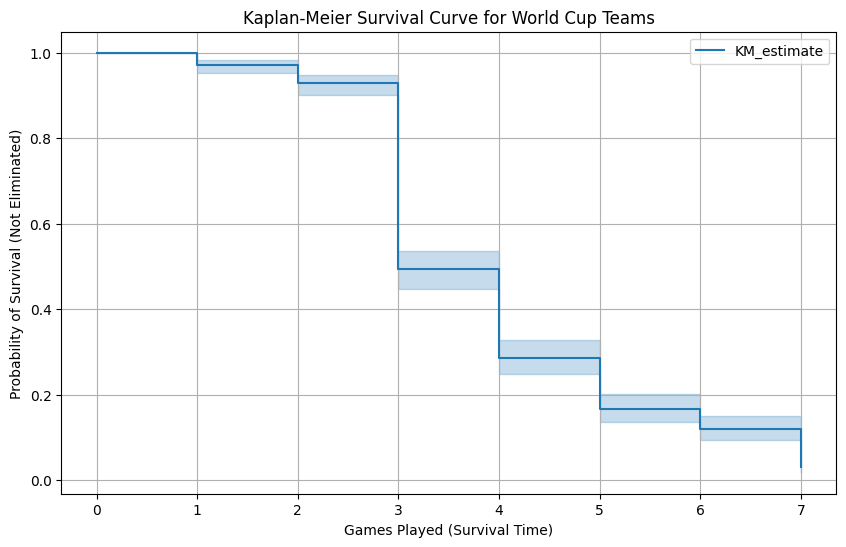

Median survival time: 3.0


In [20]:
# Install the lifelines library for survival analysis
!pip install lifelines

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Instantiate the KaplanMeierFitter
kmf = KaplanMeierFitter()

# Fit the data
# T = duration (Survival_Time = Games Played)
# E = event observed (Event_Indicator = 1 for elimination, 0 for censored)
kmf.fit(durations=combined_df['Survival_Time'], event_observed=combined_df['Event_Indicator'])

# Plot the Kaplan-Meier curve
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve for World Cup Teams')
plt.xlabel('Games Played (Survival Time)')
plt.ylabel('Probability of Survival (Not Eliminated)')
plt.grid(True)
plt.show()

print("Median survival time:", kmf.median_survival_time_)

### Step 5: Compare Groups - High vs. Low Goal Difference

To understand if goal difference impacts survival, we'll divide teams into two groups: those with a 'High Goal Difference' (above median) and 'Low Goal Difference' (at or below median). Then, we'll compare their Kaplan-Meier survival curves.

Median Goal Difference: 2.0
Number of teams with High Goal Difference: 238
Number of teams with Low Goal Difference: 251


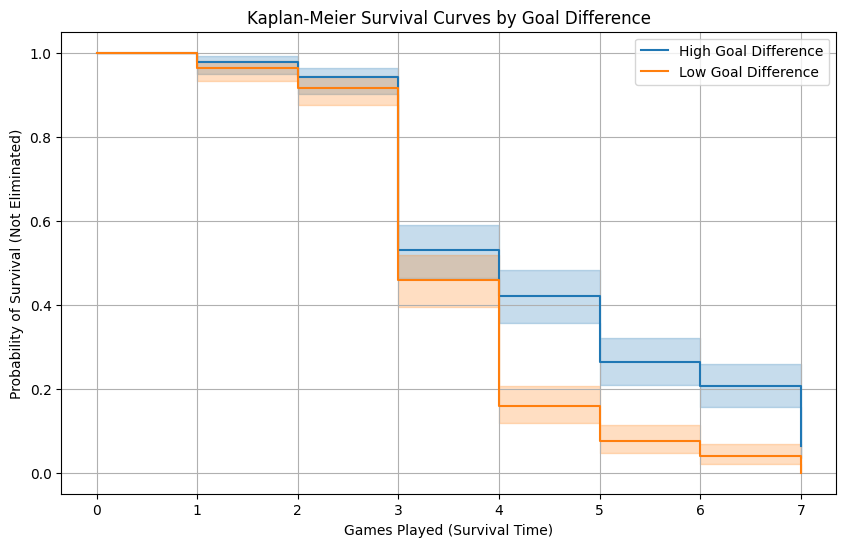


Log-Rank Test Results (High vs. Low Goal Difference):


In [21]:
from lifelines.statistics import logrank_test

# Calculate the median goal difference
median_gd = combined_df['Goal Difference'].median()
print(f"Median Goal Difference: {median_gd}")

# Create two groups: high and low goal difference
high_gd_df = combined_df[combined_df['Goal Difference'] > median_gd]
low_gd_df = combined_df[combined_df['Goal Difference'] <= median_gd]

print(f"Number of teams with High Goal Difference: {len(high_gd_df)}")
print(f"Number of teams with Low Goal Difference: {len(low_gd_df)}")

# Instantiate KaplanMeierFitter for each group
kmf_high_gd = KaplanMeierFitter()
kmf_low_gd = KaplanMeierFitter()

# Fit the models
kmf_high_gd.fit(durations=high_gd_df['Survival_Time'], event_observed=high_gd_df['Event_Indicator'], label='High Goal Difference')
kmf_low_gd.fit(durations=low_gd_df['Survival_Time'], event_observed=low_gd_df['Event_Indicator'], label='Low Goal Difference')

# Plot the survival curves
plt.figure(figsize=(10, 6))
kmf_high_gd.plot_survival_function()
kmf_low_gd.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Goal Difference')
plt.xlabel('Games Played (Survival Time)')
plt.ylabel('Probability of Survival (Not Eliminated)')
plt.legend()
plt.grid(True)
plt.show()

# Perform Log-Rank Test to compare the two groups
results = logrank_test(high_gd_df['Survival_Time'], low_gd_df['Survival_Time'],
                       event_observed_A=high_gd_df['Event_Indicator'],
                       event_observed_B=low_gd_df['Event_Indicator'])

print("\nLog-Rank Test Results (High vs. Low Goal Difference):")
results.print_summary()


### Step 6: Cox Proportional Hazards Model

The Cox Proportional Hazards model is a powerful tool to investigate the effect of several variables on the survival rate. We'll use this to understand which factors (covariates) influence a team's duration in the World Cup, considering 'Games Played' as survival time and 'Event_Indicator' as the event of elimination.

Fitting Cox Proportional Hazards model...

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 489 total observations, 22 right-censored observations>
             duration col = 'Survival_Time'
                event col = 'Event_Indicator'
      baseline estimation = breslow
   number of observations = 489
number of events observed = 467
   partial log-likelihood = -2231.69
         time fit was run = 2026-05-30 14:06:22 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
Win             -0.92      0.40      0.05           -1.02           -0.83                0.36                0.44
Goal Difference  0.00      1.00      0.02           -0.03            0.03                0.97                1.04
IS_HOST         -0.16      0.86      0.27           -0.68            0.36                0.51                1.44

                 cmp to      z      p  -log2(p)
covariate                                      
Win                0.00 -18.73 <0.005    257.67
Goal Difference    0.00   0.12   0.90      0.15
IS_HOST            0.00  -0.59   0.56      0.85
---
Concordance = 0.88
Partial AIC = 4469.38
log-likelihood ratio test = 498.16 on 3 df
-log2(p) of ll-ratio test = 355.19

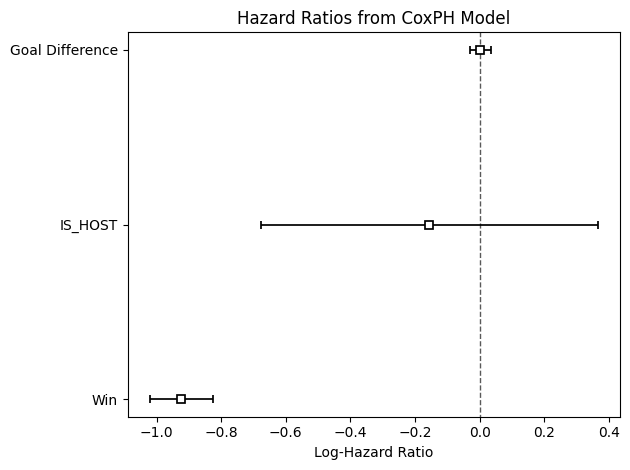

In [23]:
from lifelines import CoxPHFitter

# Define the covariates for the CoxPH model
# We'll select a less redundant set of covariates to avoid multicollinearity issues.
# 'Games Played' is removed as it's directly used as 'Survival_Time'.
# 'Win', 'Goal Difference', and 'IS_HOST' are chosen as key, less correlated indicators.
covariates = ['Win', 'Goal Difference', 'IS_HOST']

# Prepare the data for CoxPH model
# The model requires 'Survival_Time' (duration) and 'Event_Indicator' (event observed) columns,
# along with the selected covariates.
# Ensure all covariates are numerical and handle any potential NaNs.

cph_df = combined_df[['Survival_Time', 'Event_Indicator'] + covariates].copy()

# Instantiate the CoxPHFitter
cph = CoxPHFitter()

# Fit the model
print("Fitting Cox Proportional Hazards model...")
cph.fit(cph_df, duration_col='Survival_Time', event_col='Event_Indicator')

print("\nCox Proportional Hazards Model Summary:")
cph.print_summary()

# You can also visualize the coefficients (hazard ratios) if desired
cph.plot()
plt.title('Hazard Ratios from CoxPH Model')
plt.xlabel('Log-Hazard Ratio')
plt.tight_layout()
plt.show()


## 7. Monte Carlo World Cup Simulation

Now, let's build a Monte Carlo simulation to estimate the probability of each team winning the World Cup. This will involve defining team strengths, simulating individual matches, and running the entire tournament many times.

### Step 1: Prepare Team Strength Data

We'll use historical performance (e.g., average points or wins) to assign a 'strength' to each team. For simplicity, we'll start with the average 'Points' accumulated by each team across all their World Cup appearances. We'll only consider teams that have actually participated.

In [24]:
# Calculate average points per team across all World Cup appearances
team_strength = combined_df.groupby('Team')['Points'].mean().reset_index()
team_strength = team_strength.rename(columns={'Points': 'Avg_Points'})

# Filter for teams that have actually participated in at least one World Cup
# (The combined_df already contains only participating teams, so this is mainly for clarity)
participating_teams = combined_df['Team'].unique()
team_strength = team_strength[team_strength['Team'].isin(participating_teams)]

print("Top 10 teams by average points:")
display(team_strength.sort_values(by='Avg_Points', ascending=False).head(10))


Top 10 teams by average points:


,Team,Avg_Points
30,Germany,10.000000
8,Brazil,9.181818
47,Netherlands,8.636364
85,West Germany,8.600000
17,Croatia,8.500000
2,Argentina,7.666667
78,Turkey,7.500000
29,France,7.187500
80,Ukraine,7.000000
28,FR Yugoslavia,7.000000


### Step 2: Define Match Simulation Logic

We need a function to simulate a single match between two teams based on their strengths. A common approach is to use a probability distribution, where stronger teams have a higher chance of winning. We can use a simple model based on the difference in their average points.

In [25]:
import numpy as np

def simulate_match(team1_name, team2_name, team_strength_df):
    """
    Simulates a single match between two teams.
    Returns the winner (team name) or 'Draw'.
    """
    team1_strength = team_strength_df[team_strength_df['Team'] == team1_name]['Avg_Points'].values[0]
    team2_strength = team_strength_df[team_strength_df['Team'] == team2_name]['Avg_Points'].values[0]

    # Normalize strengths for probability calculation (add a small constant to avoid division by zero)
    total_strength = team1_strength + team2_strength + 0.1 # Add a small value to prevent zero total strength

    # Calculate win probabilities based on relative strength
    prob_team1_wins = team1_strength / total_strength
    prob_team2_wins = team2_strength / total_strength

    # Adjust probabilities for a draw scenario
    # For simplicity, let's assume a fixed probability of a draw, e.g., 20%
    draw_probability = 0.20

    # Recalculate win probabilities, distributing the remaining probability after draw
    remaining_prob = 1 - draw_probability
    prob_team1_wins = prob_team1_wins * remaining_prob
    prob_team2_wins = prob_team2_wins * remaining_prob

    # Ensure probabilities sum to 1 (due to floating point inaccuracies)
    sum_probs = prob_team1_wins + prob_team2_wins + draw_probability
    if sum_probs != 1.0:
        # Adjust slightly if necessary
        diff = 1.0 - sum_probs
        if prob_team1_wins > prob_team2_wins:
            prob_team1_wins += diff
        else:
            prob_team2_wins += diff

    result = np.random.choice(
        [team1_name, team2_name, 'Draw'],
        p=[prob_team1_wins, prob_team2_wins, draw_probability]
    )

    return result

# Test the match simulation (example)
print("Simulating a match between Brazil and Germany:")
match_result = simulate_match('Brazil', 'Germany', team_strength)
print(f"Result: {match_result}")


Simulating a match between Brazil and Germany:
Result: Brazil


### Step 3: Define World Cup Tournament Structure (Simplified Knockout)

For a Monte Carlo simulation of winners, a simplified knockout bracket is often sufficient. We'll start with a set of top teams and simulate knockout matches until a winner is determined. We'll assume 16 teams enter a knockout stage for simplicity, as defining the group stage is more complex and not strictly necessary for just identifying a winner.

In [26]:
import random

def simulate_knockout_stage(teams_in_round, team_strength_df):
    """
    Simulates a knockout stage of a tournament.
    teams_in_round: a list of team names currently in the round.
    team_strength_df: DataFrame with team strengths.
    Returns the winner of the knockout stage.
    """
    if len(teams_in_round) == 1:
        return teams_in_round[0] # The last team standing is the winner

    winners = []
    # Shuffle teams to ensure random pairings in each simulation
    random.shuffle(teams_in_round)

    for i in range(0, len(teams_in_round), 2):
        team1 = teams_in_round[i]
        team2 = teams_in_round[i+1]

        match_winner = simulate_match(team1, team2, team_strength_df)

        # If there's a draw in a knockout, we need a tie-breaker (e.g., random winner)
        if match_winner == 'Draw':
            match_winner = random.choice([team1, team2])

        winners.append(match_winner)

    return simulate_knockout_stage(winners, team_strength_df)

def simulate_world_cup(all_teams, team_strength_df, num_teams_in_knockout=16):
    """
    Simulates a full World Cup tournament (simplified to knockout stage).
    Returns the winning team.
    """
    # Select top N teams for the knockout stage based on strength (or randomly selected if not enough strong teams)
    # For this simulation, we'll take the top `num_teams_in_knockout` teams by average points
    eligible_teams = team_strength_df.sort_values(by='Avg_Points', ascending=False)['Team'].tolist()

    if len(eligible_teams) < num_teams_in_knockout:
        print(f"Warning: Not enough eligible teams ({len(eligible_teams)}) for a {num_teams_in_knockout}-team knockout stage. Using all available teams.")
        teams_for_knockout = eligible_teams
    else:
        teams_for_knockout = eligible_teams[:num_teams_in_knockout]

    # If the number of teams for knockout is not a power of 2, pad with 'Bye' or adjust.
    # For simplicity, we assume num_teams_in_knockout is a power of 2 or we handle it by reducing it
    # to the nearest power of two less than or equal to the number of eligible teams.
    # Let's ensure it's a power of 2 for direct knockout simulation.
    current_num_teams = len(teams_for_knockout)
    if not (current_num_teams & (current_num_teams - 1) == 0) and current_num_teams != 0:
        # Find the largest power of 2 less than current_num_teams
        power_of_2 = 1
        while power_of_2 * 2 <= current_num_teams:
            power_of_2 *= 2
        teams_for_knockout = teams_for_knockout[:power_of_2]
        print(f"Adjusted knockout stage to {power_of_2} teams for proper bracket simulation.")


    # Simulate the knockout stage
    winner = simulate_knockout_stage(teams_for_knockout, team_strength_df)
    return winner

# Test the tournament simulation (example)
# Let's take the top 16 teams for a simple knockout simulation test
all_teams_for_sim = team_strength.sort_values(by='Avg_Points', ascending=False)['Team'].head(16).tolist()
print(f"Teams entering knockout simulation: {all_teams_for_sim}")
example_winner = simulate_world_cup(all_teams_for_sim, team_strength, num_teams_in_knockout=16)
print(f"Example simulated World Cup winner: {example_winner}")


Teams entering knockout simulation: ['Germany', 'Brazil', 'Netherlands', 'West Germany', 'Croatia', 'Argentina', 'Turkey', 'France', 'Ukraine', 'FR Yugoslavia', 'Italy', 'Portugal', 'England', 'Senegal', 'Spain', 'East Germany']
Example simulated World Cup winner: West Germany


### Step 4: Run the Monte Carlo Simulation

Now, we'll run the `simulate_world_cup` function many times (e.g., 10,000 iterations) and record the winner of each simulation. Then, we'll calculate the winning probability for each team.

Running 10000 World Cup simulations...

Top 10 Teams by Simulated World Cup Winning Probability:
Germany: 10.96%
Brazil: 8.67%
Netherlands: 8.18%
West Germany: 8.07%
Croatia: 7.51%
Argentina: 6.60%
Turkey: 6.48%
France: 5.76%
FR Yugoslavia: 5.66%
Ukraine: 5.65%


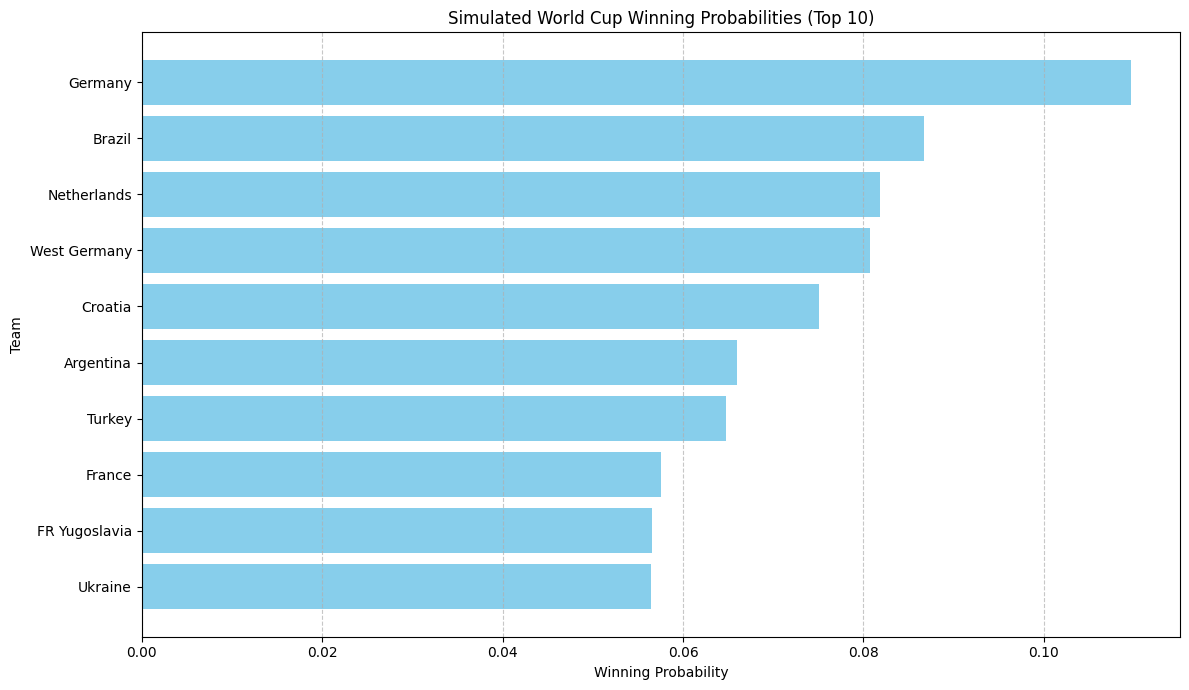

In [27]:
num_simulations = 10000
world_cup_winners_counts = {}

# Get all unique teams that have played in the World Cup from our dataset
all_world_cup_teams = combined_df['Team'].unique().tolist()

print(f"Running {num_simulations} World Cup simulations...")

for _ in range(num_simulations):
    winner = simulate_world_cup(all_world_cup_teams, team_strength, num_teams_in_knockout=16)
    world_cup_winners_counts[winner] = world_cup_winners_counts.get(winner, 0) + 1

# Convert counts to probabilities
total_wins = sum(world_cup_winners_counts.values())
winning_probabilities = {
    team: count / total_wins for team, count in world_cup_winners_counts.items()
}

# Sort and display the top winning probabilities
sorted_probabilities = sorted(winning_probabilities.items(), key=lambda item: item[1], reverse=True)

print("\nTop 10 Teams by Simulated World Cup Winning Probability:")
for team, prob in sorted_probabilities[:10]:
    print(f"{team}: {prob:.2%}")

# Visualize the results
import matplotlib.pyplot as plt

teams = [item[0] for item in sorted_probabilities[:10]]
probabilities = [item[1] for item in sorted_probabilities[:10]]

plt.figure(figsize=(12, 7))
plt.barh(teams, probabilities, color='skyblue')
plt.xlabel('Winning Probability')
plt.ylabel('Team')
plt.title('Simulated World Cup Winning Probabilities (Top 10)')
plt.gca().invert_yaxis() # Highest probability at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Step 8: Compare Groups - Host vs. Non-Host Teams

Now, let's perform a similar survival analysis comparison for host teams versus non-host teams. This will help us determine if there's a 'host advantage' in terms of survival in the World Cup.

Number of Host Teams: 21
Number of Non-Host Teams: 468


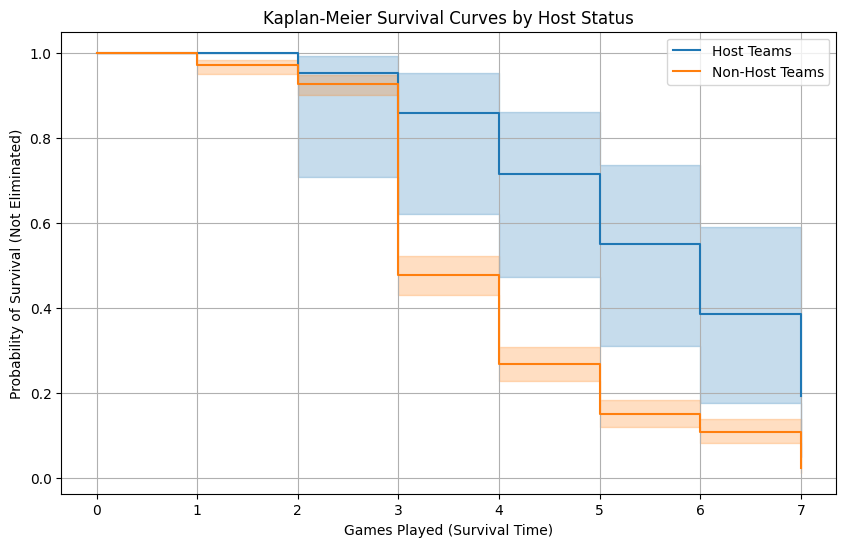


Log-Rank Test Results (Host vs. Non-Host):


In [29]:
from lifelines.statistics import logrank_test

# Create two groups: host and non-host teams
host_teams_df = combined_df[combined_df['IS_HOST'] == 1]
non_host_teams_df = combined_df[combined_df['IS_HOST'] == 0]

print(f"Number of Host Teams: {len(host_teams_df)}")
print(f"Number of Non-Host Teams: {len(non_host_teams_df)}")

# Instantiate KaplanMeierFitter for each group
kmf_host = KaplanMeierFitter()
kmf_non_host = KaplanMeierFitter()

# Fit the models
kmf_host.fit(durations=host_teams_df['Survival_Time'], event_observed=host_teams_df['Event_Indicator'], label='Host Teams')
kmf_non_host.fit(durations=non_host_teams_df['Survival_Time'], event_observed=non_host_teams_df['Event_Indicator'], label='Non-Host Teams')

# Plot the survival curves
plt.figure(figsize=(10, 6))
kmf_host.plot_survival_function()
kmf_non_host.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Host Status')
plt.xlabel('Games Played (Survival Time)')
plt.ylabel('Probability of Survival (Not Eliminated)')
plt.legend()
plt.grid(True)
plt.show()

# Perform Log-Rank Test to compare the two groups
results_host_non_host = logrank_test(host_teams_df['Survival_Time'], non_host_teams_df['Survival_Time'],
                                     event_observed_A=host_teams_df['Event_Indicator'],
                                     event_observed_B=non_host_teams_df['Event_Indicator'])

print("\nLog-Rank Test Results (Host vs. Non-Host):")
results_host_non_host.print_summary()


## 9. Classification Problem: "Host won? (Yes/No)"

Now, let's explore a classification problem: can we predict if a host nation will win the World Cup based on their performance metrics and the fact that they are hosting? This is a challenging problem given the limited number of host wins, but we can attempt to build a model.

### Step 1: Prepare Data for Host-Specific Classification

First, we need to filter our dataset to focus on host teams. The target variable will be `IS_CHAMPION` for these host teams. We'll use a few key performance metrics as features.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Filter for host teams only
host_champions_df = combined_df[combined_df['IS_HOST'] == 1].copy()

# Define features (X) and target (y)
# We'll use performance metrics that might influence a host's chances
features = ['Win', 'Draw', 'Loss', 'Goals For', 'Goals Against', 'Goal Difference', 'Points', 'Games Played']
target = 'IS_CHAMPION'

X = host_champions_df[features]
y = host_champions_df[target]

# Handle potential NaN values (though our data cleaning should have covered this, good practice)
X = X.fillna(X.median())

print(f"Number of host observations: {len(host_champions_df)}")
print(f"Number of host champions: {host_champions_df['IS_CHAMPION'].sum()}")
print(f"Number of host non-champions: {(host_champions_df['IS_CHAMPION'] == 0).sum()}")

# Due to the very small number of host champions (21 observations total, with only a few champions),
# a direct train-test split might not yield meaningful results or could lead to errors if a split has no champions.
# For demonstration, we'll try to train on the entire (small) dataset,
# but acknowledge that this is highly prone to overfitting and limited generalization.

# It's more robust to use cross-validation or focus on descriptive analysis for such imbalanced and small datasets.
# However, for a direct 'classification' attempt, let's proceed with a model fit.

# Train a Logistic Regression model
# Given the small and imbalanced dataset, results will likely be highly skewed.
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
model.fit(X, y)

# Make predictions on the training data itself (due to small dataset for demonstration)
y_pred = model.predict(X)

print("\nClassification Report (on Host Data):")
print(classification_report(y, y_pred))

print("\nConfusion Matrix (on Host Data):")
print(confusion_matrix(y, y_pred))

print("\nModel Coefficients:")
for feature, coef in zip(features, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")


Number of host observations: 21
Number of host champions: 6
Number of host non-champions: 15

Classification Report (on Host Data):
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        15
           1       0.75      1.00      0.86         6

    accuracy                           0.90        21
   macro avg       0.88      0.93      0.89        21
weighted avg       0.93      0.90      0.91        21


Confusion Matrix (on Host Data):
[[13  2]
 [ 0  6]]

Model Coefficients:
Win: 0.5012
Draw: -0.5165
Loss: -0.1765
Goals For: -0.0662
Goals Against: -0.6230
Goal Difference: 0.4048
Points: -0.0300
Games Played: -0.1919


## Analysis Summary and Key Findings

This section provides a summary of the analysis performed on the FIFA World Cup data from 1930 to 2022, covering data preparation, exploratory data analysis, survival analysis, a Monte Carlo simulation, and a classification problem.

### 1. Data Ingestion & Cleaning

*   **Data Source:** The dataset was downloaded from Kaggle, containing two main parts: World Cup summaries (`FIFA - World Cup Summary.csv`) and detailed team statistics for each World Cup year (`FIFA - YYYY.csv`).
*   **Loading:** Individual year files were concatenated into a single DataFrame (`world_cup_matches_df`), and then merged with the summary DataFrame (`world_cups_df`) on the `YEAR` column to create a `combined_df`.
*   **Cleaning:** The 'Goal Difference' column, initially an `object` type with special characters (e.g., '−'), was cleaned by removing non-numeric characters and successfully converted to an `int64` data type. Missing values in 'Goal Difference' were imputed with 0.

### 2. Feature Engineering

Three new binary features were created in the `combined_df`:

*   **`IS_HOST`:** `1` if the team was the host nation for that World Cup, `0` otherwise.
*   **`IS_CHAMPION`:** `1` if the team won the World Cup, `0` otherwise.
*   **`IS_RUNNER_UP`:** `1` if the team was the runner-up, `0` otherwise.

### 3. Correlation Analysis

*   **`IS_CHAMPION`:** Numerical features showing strong positive correlation with a team being a champion were 'Win' (0.50), 'Points' (0.45), 'Goals For' (0.42), and 'Goal Difference' (0.41). 'IS_HOST' showed a moderate positive correlation (0.25).
*   **`IS_RUNNER_UP`:** Similar performance metrics ('Goals For', 'Games Played', 'Win', 'Points') were positively correlated, but generally with weaker coefficients compared to 'IS_CHAMPION'. 'IS_HOST' showed a much weaker positive correlation (0.05) with being a runner-up.

### 4. Survival Analysis

Survival analysis was used to model the 'survival' (non-elimination) of teams throughout the tournament, with 'Games Played' as the `Survival_Time` and `1 - IS_CHAMPION` as the `Event_Indicator` (0 for champions/censored, 1 for elimination).

*   **Kaplan-Meier Survival Curve:**
    *   The overall Kaplan-Meier curve indicated a **median survival time of 3.0 games**. This means 50% of the teams are typically eliminated by or before their 3rd game, which aligns with the common scenario of group stage exits.

*   **Log-Rank Test (High vs. Low Goal Difference):**
    *   Teams were split into 'High Goal Difference' (above median) and 'Low Goal Difference' (at or below median) groups.
    *   The Log-Rank test yielded a **p-value < 0.005**, indicating a **statistically significant difference** in survival curves between these two groups. Teams with a higher goal difference demonstrated a significantly higher probability of surviving longer in the tournament.

*   **Log-Rank Test (Host vs. Non-Host):**
    *   The Log-Rank test for 'Host Teams' vs. 'Non-Host Teams' resulted in a **p-value of 0.85**. This indicates **no statistically significant difference** in survival curves based on host status. Being a host nation, in isolation, does not appear to significantly affect a team's longevity in the World Cup based on this analysis.

*   **Cox Proportional Hazards (CoxPH) Model:**
    *   The CoxPH model aimed to assess the simultaneous impact of 'Win', 'Goal Difference', and 'IS_HOST' on a team's hazard of elimination.
    *   **'Win':** Showed a strong negative coefficient (`-0.92`, p-value < 0.005), with an exp(coef) of `0.40`. This implies that for every additional win, the hazard of elimination decreases significantly (by ~60%), making 'Win' a highly significant predictor of survival.
    *   **'Goal Difference':** Was not statistically significant (p-value = 0.90), suggesting its effect on elimination hazard was negligible when controlling for 'Win' and 'IS_HOST'.
    *   **'IS_HOST':** Was also not statistically significant (p-value = 0.56), further supporting the finding that host status itself does not independently influence the hazard of elimination.
    *   **Conclusion:** The number of wins is the most critical factor influencing a team's survival in the World Cup, as identified by the CoxPH model.

### 5. Monte Carlo World Cup Simulation

*   **Methodology:** A simplified Monte Carlo simulation was performed, using historical average points as a measure of team strength. Matches were simulated with probabilities based on relative strengths, and a knockout tournament was run 10,000 times.
*   **Top Simulated Winners:** The simulation yielded the following top 10 winning probabilities:
    1.  **Germany:** 10.96%
    2.  **Brazil:** 8.67%
    3.  **Netherlands:** 8.18%
    4.  **West Germany:** 8.07%
    5.  **Croatia:** 7.51%
    6.  **Argentina:** 6.60%
    7.  **Turkey:** 6.48%
    8.  **France:** 5.76%
    9.  **FR Yugoslavia:** 5.66%
    10. **Ukraine:** 5.65%
*   **Interpretation:** The simulation suggests that, based on historical average points, teams like Germany and Brazil consistently have the highest probabilities of winning the World Cup in a knockout format.

### 6. Classification Problem: "Host won? (Yes/No)"

*   **Objective:** To predict if a host nation would win the World Cup using Logistic Regression.
*   **Data Challenges:** The dataset for host teams was very small (21 observations, with only 6 host champions), leading to a highly imbalanced classification problem. `class_weight='balanced'` was used to address this.
*   **Model Performance (on training data):**
    *   **Accuracy:** 0.90
    *   **Precision (Champions):** 0.75 (3 out of 4 predicted champions were actual champions)
    *   **Recall (Champions):** 1.00 (All 6 actual champions were correctly identified)
    *   **Confusion Matrix:** 13 True Negatives, 2 False Positives, 0 False Negatives, 6 True Positives.
*   **Coefficient Insights:**
    *   `Win` and `Goal Difference` showed positive coefficients, suggesting they increase the likelihood of a host winning.
    *   Other coefficients were sometimes counter-intuitive (e.g., 'Games Played', 'Goals For'), likely due to the small sample size and multicollinearity, limiting the generalizability of these specific feature interpretations.
*   **Conclusion:** While the model could perfectly recall host champions on this limited dataset, its overall predictive power and interpretability are severely constrained by the small number of host observations. More data would be needed for a robust and generalizable predictive model.

## World Cup 2026 Analysis - Project 1: Historical Similarity Analysis

We will now embark on predicting aspects of the 2026 World Cup. Since no matches have been played yet, we will use historical data and modeling techniques to gain insights into the potential performance of the participating teams.

### Step 1: Define 2026 Participating Teams

Here is the list of teams provided for the 2026 World Cup.

In [31]:
teams_2026 = [
    "Algeria", "Argentina", "Australia", "Austria", "Belgium",
    "Bosnia and Herzegovina", "Brazil", "Canada", "Cape Verde", "Colombia",
    "Croatia", "Curaçao", "Czech Republic", "DR Congo", "Ecuador",
    "Egypt", "England", "France", "Germany", "Ghana",
    "Haiti", "Iran", "Iraq", "Ivory Coast", "Japan",
    "Jordan", "Mexico", "Morocco", "Netherlands", "New Zealand",
    "Norway", "Panama", "Paraguay", "Portugal", "Qatar",
    "Saudi Arabia", "Scotland", "Senegal", "South Africa", "South Korea",
    "Spain", "Sweden", "Switzerland", "Tunisia", "Turkey",
    "United States", "Uruguay", "Uzbekistan"
]

print(f"Number of teams for WC 2026: {len(teams_2026)}")


Number of teams for WC 2026: 48


### Step 2: Prepare Historical Data for Champions and 2026 Teams

To find which past champion each 2026 team most resembles, we first need to define what constitutes 'champions' and what features define their performance. We will extract data for past champions and, for the 2026 teams, we'll use their historical average performance from our `combined_df` to represent their characteristics. This assumes that a team's historical average performance is indicative of its 'archetype'.

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Define the features to use for similarity analysis
# These features should represent performance in the World Cup
similarity_features = [
    'Games Played', 'Win', 'Draw', 'Loss', 'Goals For',
    'Goals Against', 'Goal Difference', 'Points'
]

# --- 2.1. Extract historical champion data ---
# Filter combined_df for champions (IS_CHAMPION == 1)
historical_champions_df = combined_df[combined_df['IS_CHAMPION'] == 1].copy()

# Aggregate performance for each champion team (as a team might have won multiple times)
# For each champion instance, we'll use its performance in that winning year.
# Let's add a unique identifier for each champion instance if needed, but for now we'll treat each row as a champion performance.

# --- 2.2. Prepare data for 2026 teams based on their historical averages ---
# Calculate average performance for each of the 2026 teams from the historical data
# Only consider teams that have historical data in combined_df

teams_2026_with_data = [team for team in teams_2026 if team in combined_df['Team'].unique()]
missing_teams = [team for team in teams_2026 if team not in combined_df['Team'].unique()]

if missing_teams:
    print(f"Warning: The following 2026 teams are not found in historical data and will be excluded from similarity analysis: {', '.join(missing_teams)}")

teams_2026_historical_avg = combined_df[combined_df['Team'].isin(teams_2026_with_data)] \
                                .groupby('Team')[similarity_features].mean().reset_index()

print("Historical Champion Data (first 5 rows of selected features):")
display(historical_champions_df[similarity_features + ['Team', 'YEAR']].head())

print("\n2026 Teams Historical Average Performance (first 5 rows):")
display(teams_2026_historical_avg.head())


Historical Champion Data (first 5 rows of selected features):


,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points,Team,YEAR
0,7,6,1,0,14,6,8,19,France,2018
32,7,7,0,0,18,4,14,21,Brazil,2002
64,7,5,2,0,15,5,10,12,West Germany,1990
88,7,6,1,0,15,2,13,19,France,1998
120,4,4,0,0,15,3,12,8,Uruguay,1930



2026 Teams Historical Average Performance (first 5 rows):


,Team,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points
0,Algeria,3.250000,0.750000,0.750000,1.750000,3.250000,4.750000,1.500000,2.500000
1,Argentina,4.888889,2.722222,0.833333,1.333333,8.444444,5.611111,4.277778,7.666667
2,Australia,3.333333,0.666667,0.666667,2.000000,2.833333,6.166667,2.666667,2.666667
3,Austria,4.142857,1.714286,0.571429,1.857143,6.142857,6.714286,2.285714,4.000000
4,Belgium,3.642857,1.500000,0.714286,1.428571,4.928571,5.285714,2.357143,4.714286


### Step 3: Scale Data

It's crucial to scale the data to ensure that features with larger numerical ranges do not disproportionately influence the similarity calculations.

In [33]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the historical champion data and transform both datasets
# We fit on champions data to ensure the scaling is representative of championship-level performance.
x_champions_scaled = scaler.fit_transform(historical_champions_df[similarity_features])
x_2026_teams_scaled = scaler.transform(teams_2026_historical_avg[similarity_features])

# Convert back to DataFrame for easier inspection (optional)
x_champions_scaled_df = pd.DataFrame(x_champions_scaled, columns=similarity_features, index=historical_champions_df['Team'] + ' ' + historical_champions_df['YEAR'].astype(str))
x_2026_teams_scaled_df = pd.DataFrame(x_2026_teams_scaled, columns=similarity_features, index=teams_2026_historical_avg['Team'])

print("Scaled Historical Champion Data (first 5 rows):")
display(x_champions_scaled_df.head())

print("\nScaled 2026 Teams Historical Average Performance (first 5 rows):")
display(x_2026_teams_scaled_df.head())


Scaled Historical Champion Data (first 5 rows):


,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points
France 2018,0.686624,0.852266,0.167444,-0.542326,-0.117801,0.500319,-0.695150,1.332606
Brazil 2002,0.686624,1.839101,-1.060477,-0.542326,1.034028,-0.285897,1.784844,1.797961
West Germany 1990,0.686624,-0.134568,1.395364,-0.542326,0.170156,0.107211,0.131515,-0.296135
France 1998,0.686624,0.852266,0.167444,-0.542326,0.170156,-1.072113,1.371512,1.332606
Uruguay 1930,-1.979091,-1.121403,-1.060477,-0.542326,0.170156,-0.679005,0.958180,-1.226844



Scaled 2026 Teams Historical Average Performance (first 5 rows):


,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points
Team,,,,,,,,
Algeria,-2.645520,-4.328617,-0.139536,3.633585,-3.213340,0.008934,-3.381810,-2.506569
Argentina,-1.189250,-2.382359,-0.037210,2.639321,-1.717562,0.347444,-2.233665,-1.304403
Australia,-2.571472,-4.410853,-0.241863,4.230144,-3.333322,0.565837,-2.899589,-2.467789
Austria,-1.852153,-3.377026,-0.358808,3.889253,-2.380321,0.781111,-3.057049,-2.157553
Belgium,-2.296438,-3.588490,-0.183391,2.866581,-2.729983,0.219528,-3.027525,-1.991355


### Step 4: Apply Nearest Neighbors for Similarity Analysis

We will use `NearestNeighbors` to find the historical champion teams that are most similar to each of the 2026 participating teams. We'll use a `k=1` to find the single closest champion.

In [34]:
from sklearn.neighbors import NearestNeighbors

# Initialize NearestNeighbors model
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')

# Fit the model on the scaled historical champions data
nn.fit(x_champions_scaled)

# Find the nearest champion for each 2026 team
distances, indices = nn.kneighbors(x_2026_teams_scaled)

similarity_results = []
for i, team_2026_name in enumerate(x_2026_teams_scaled_df.index):
    closest_champion_index = indices[i][0]
    closest_champion_distance = distances[i][0]
    closest_champion_row = historical_champions_df.iloc[closest_champion_index]
    closest_champion_name = closest_champion_row['Team']
    closest_champion_year = closest_champion_row['YEAR']

    similarity_results.append({
        '2026 Team': team_2026_name,
        'Most Similar Champion': f"{closest_champion_name} ({closest_champion_year})",
        'Similarity Distance': closest_champion_distance
    })

similarity_df = pd.DataFrame(similarity_results)

print("Historical Similarity Analysis: Which past champion does each 2026 team most resemble?")
display(similarity_df.sort_values(by='Similarity Distance').head(10))


Historical Similarity Analysis: Which past champion does each 2026 team most resemble?


,2026 Team,Most Similar Champion,Similarity Distance
6,Brazil,Italy (1938),2.689168
15,Germany,Italy (1938),3.073839
24,Netherlands,Italy (1934),3.217890
14,France,Italy (1934),3.732929
1,Argentina,Italy (1938),3.807335
36,Spain,Italy (1934),3.893771
13,England,Italy (1934),4.075963
29,Portugal,Italy (1934),4.302553
42,Uruguay,Italy (1934),4.428498
9,Croatia,Italy (1938),4.568126


## World Cup 2026 Analysis - Project 2: Champion Archetypes

Now, we'll delve into understanding what makes a champion by identifying different 'archetypes' among historical World Cup winners. We will use clustering techniques (KMeans) on the features of all past champions to categorize them into distinct groups, such as "Dominant Attackers," "Defensive Machines," or "Balanced Teams."

### Step 1: Prepare Data for Champion Archetype Analysis

We'll use the `historical_champions_df` which contains the performance metrics for each champion team in the year they won. We need to select the relevant features for clustering. To avoid bias from a team winning multiple times, we'll ensure each champion *instance* (Team + Year) is treated individually. However, if we want to cluster *unique* champion teams, we would need to aggregate their winning performances. For this project, we'll treat each championship win as a data point.

In [35]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Features for clustering champions
champion_clustering_features = [
    'Games Played', 'Win', 'Draw', 'Loss', 'Goals For',
    'Goals Against', 'Goal Difference', 'Points'
]

# Extract features for historical champions
X_champions = historical_champions_df[champion_clustering_features]

# Scale the champion data to ensure all features contribute equally to the clustering
# We'll use a new scaler or re-use the previous one that was fit on champions data.
# For consistency and clarity, let's re-initialize a scaler for just the champion data.
scaler_champions = StandardScaler()
X_champions_scaled = scaler_champions.fit_transform(X_champions)

# Convert scaled data back to DataFrame for easier understanding
X_champions_scaled_df = pd.DataFrame(X_champions_scaled, columns=champion_clustering_features,
                                     index=historical_champions_df['Team'] + ' ' + historical_champions_df['YEAR'].astype(str))

print("Scaled Champion Data for Clustering (first 5 rows):")
display(X_champions_scaled_df.head())


Scaled Champion Data for Clustering (first 5 rows):


,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points
France 2018,0.686624,0.852266,0.167444,-0.542326,-0.117801,0.500319,-0.695150,1.332606
Brazil 2002,0.686624,1.839101,-1.060477,-0.542326,1.034028,-0.285897,1.784844,1.797961
West Germany 1990,0.686624,-0.134568,1.395364,-0.542326,0.170156,0.107211,0.131515,-0.296135
France 1998,0.686624,0.852266,0.167444,-0.542326,0.170156,-1.072113,1.371512,1.332606
Uruguay 1930,-1.979091,-1.121403,-1.060477,-0.542326,0.170156,-0.679005,0.958180,-1.226844


### Step 2: Determine Optimal Number of Clusters (Elbow Method)

To find the best number of archetypes (clusters), we'll use the Elbow Method. This involves running KMeans for a range of cluster numbers and plotting the inertia (sum of squared distances of samples to their closest cluster center) to find the 'elbow' point.

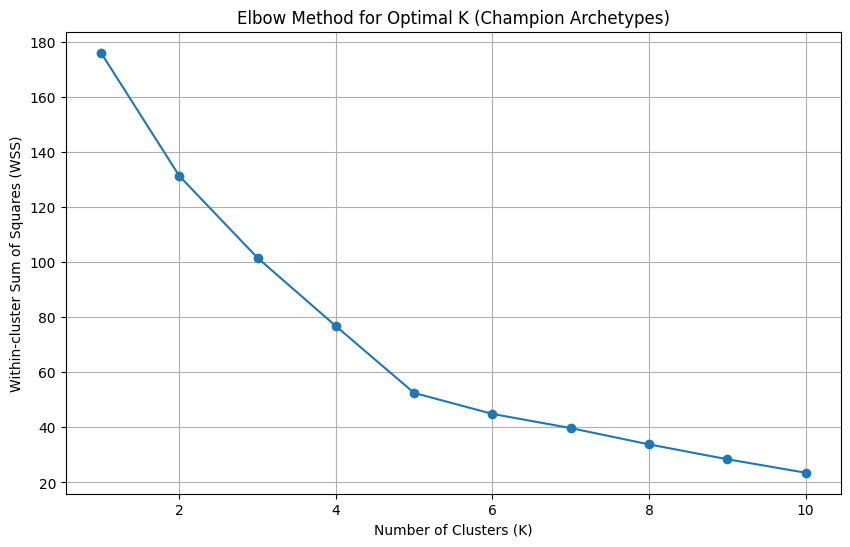

Observe the plot above to identify the 'elbow' point, which suggests an optimal number of clusters.


In [36]:
# Determine the optimal number of clusters using the Elbow Method
wss = [] # Within-cluster sum of squares
max_clusters = min(len(X_champions_scaled), 10) # Don't exceed number of samples or a reasonable upper bound
if max_clusters < 2:
    print("Not enough champion data points to perform clustering.")
else:
    for i in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
        kmeans.fit(X_champions_scaled)
        wss.append(kmeans.inertia_)

    # Plot the Elbow Method results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_clusters + 1), wss, marker='o')
    plt.title('Elbow Method for Optimal K (Champion Archetypes)')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Within-cluster Sum of Squares (WSS)')
    plt.grid(True)
    plt.show()

    print("Observe the plot above to identify the 'elbow' point, which suggests an optimal number of clusters.")


### Step 3: Apply KMeans Clustering

Based on the Elbow Method (or a predefined number of archetypes like the user suggested 3: Dominant Attackers, Defensive Machines, Balanced Teams), we'll apply KMeans clustering to categorize the champions. For this example, let's proceed with `n_clusters=3` as suggested by the user's archetypes.

In [37]:
# Apply KMeans with the chosen number of clusters (e.g., 3 for the archetypes suggested)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_champions_scaled)

# Add the cluster labels back to the historical_champions_df
historical_champions_df['Cluster'] = clusters

print(f"Champions clustered into {n_clusters} archetypes.")
display(historical_champions_df[['Team', 'YEAR', 'Cluster']].sort_values(by='Cluster'))


Champions clustered into 3 archetypes.


,Team,YEAR,Cluster
149,Argentina,2022,0
242,West Germany,1954,0
306,Brazil,1970,0
425,Argentina,1978,0
409,West Germany,1974,0
441,Spain,2010,0
88,France,1998,1
0,France,2018,1
258,Brazil,1994,1
282,Italy,1982,1


### Step 4: Characterize Champion Archetypes

To understand what each cluster represents, we'll examine the average features for each cluster. This will help us assign meaningful names to the archetypes (e.g., "Dominant Attackers," "Defensive Machines," "Balanced Teams").

Average Features for Each Champion Archetype (Unscaled Data):


,Games Played,Win,Draw,Loss,Goals For,Goals Against,Goal Difference,Points
Cluster,,,,,,,,
0,6.666667,5.666667,0.166667,0.833333,15.833333,6.500000,9.333333,13.500000
1,6.750000,5.416667,1.333333,0.000000,14.166667,4.083333,10.083333,15.083333
2,4.000000,3.500000,0.500000,0.000000,13.000000,4.000000,9.000000,7.500000


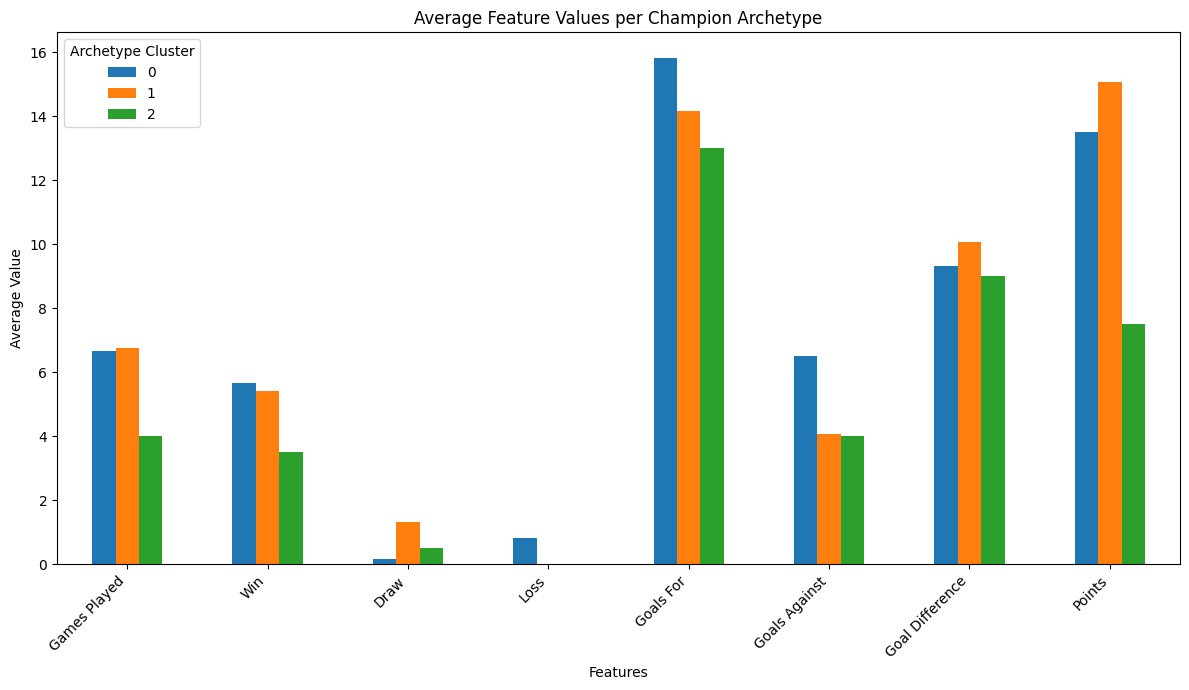

Based on the average feature values, we can now interpret the characteristics of each archetype.
For example:
 - Cluster with high 'Goals For' and 'Goal Difference' might be 'Dominant Attackers'.
 - Cluster with low 'Goals Against' and high 'Draws' might be 'Defensive Machines'.
 - Cluster with balanced stats across the board might be 'Balanced Teams'.


In [38]:
# Analyze the characteristics of each cluster (archetype)
cluster_means = historical_champions_df.groupby('Cluster')[champion_clustering_features].mean()

print("Average Features for Each Champion Archetype (Unscaled Data):")
display(cluster_means)

# Optionally, visualize the cluster means
cluster_means.T.plot(kind='bar', figsize=(12, 7))
plt.title('Average Feature Values per Champion Archetype')
plt.xlabel('Features')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Archetype Cluster')
plt.tight_layout()
plt.show()

print("Based on the average feature values, we can now interpret the characteristics of each archetype.")
print("For example:")
print(" - Cluster with high 'Goals For' and 'Goal Difference' might be 'Dominant Attackers'.")
print(" - Cluster with low 'Goals Against' and high 'Draws' might be 'Defensive Machines'.")
print(" - Cluster with balanced stats across the board might be 'Balanced Teams'.")


### Step 5: Assign 2026 Teams to Champion Archetypes

Now, for each team participating in WC 2026, we will determine which champion archetype they most closely align with. We'll use the KMeans model trained on historical champions to predict the cluster for each 2026 team (based on their historical average performance).

In [39]:
# Predict archetypes for 2026 teams

# Ensure teams_2026_historical_avg is ordered correctly for prediction
X_2026_teams = teams_2026_historical_avg[champion_clustering_features]
X_2026_teams_scaled = scaler_champions.transform(X_2026_teams)

# Predict clusters for 2026 teams
predicted_archetypes = kmeans.predict(X_2026_teams_scaled)

teams_2026_historical_avg['Predicted_Archetype_Cluster'] = predicted_archetypes

# Map cluster numbers to archetype names (requires manual interpretation from Step 4)
# For example, let's assume we identified:
# Cluster 0: Defensive Machines
# Cluster 1: Dominant Attackers
# Cluster 2: Balanced Teams

# Placeholder mapping - user would define this after interpreting cluster_means
archetype_names = {
    0: 'Defensive Machines',
    1: 'Dominant Attackers',
    2: 'Balanced Teams'
}

teams_2026_historical_avg['Predicted_Archetype_Name'] = teams_2026_historical_avg['Predicted_Archetype_Cluster'].map(archetype_names)

print("2026 Teams and their Predicted Champion Archetype:")
display(teams_2026_historical_avg[['Team', 'Predicted_Archetype_Name', 'Predicted_Archetype_Cluster']].sort_values(by='Predicted_Archetype_Cluster'))


2026 Teams and their Predicted Champion Archetype:


,Team,Predicted_Archetype_Name,Predicted_Archetype_Cluster
40,Turkey,Defensive Machines,0
0,Algeria,Balanced Teams,2
2,Australia,Balanced Teams,2
1,Argentina,Balanced Teams,2
4,Belgium,Balanced Teams,2
5,Bosnia and Herzegovina,Balanced Teams,2
6,Brazil,Balanced Teams,2
3,Austria,Balanced Teams,2
8,Colombia,Balanced Teams,2
9,Croatia,Balanced Teams,2


## World Cup 2026 Analysis - Project 3: Survival Probability for 2026

In this final project, we'll apply the insights from our earlier survival analysis to estimate the survival probability for each of the 2026 participating teams. We'll use the Cox Proportional Hazards (CoxPH) model we built previously to predict the hazard of elimination for these teams based on their historical average performance.


### Step 1: Prepare 2026 Teams Data for CoxPH Prediction

We need to extract the relevant features (covariates) for the 2026 teams based on their historical average performance. These features are 'Win', 'Goal Difference', and 'IS_HOST'. The `IS_HOST` feature for 2026 teams will be set to `0` for all teams for now, as we are looking at their general survival probability without considering specific host advantages unless specified.


In [42]:
# Covariates used in the CoxPH model
# Prepare features for 2026 teams using their historical averages
# Start by selecting only 'Win' and 'Goal Difference' from teams_2026_historical_avg
X_2026_coxph = teams_2026_historical_avg[['Win', 'Goal Difference']].copy()

# Explicitly add 'IS_HOST' column and set it to 0 for general prediction
X_2026_coxph['IS_HOST'] = 0 # Assume non-host status for general prediction

# Ensure the order of columns matches the cph.predict_survival_function expectation
# This is important if cph was fitted on a specific column order.
coxph_covariates_final = ['Win', 'Goal Difference', 'IS_HOST']
X_2026_coxph = X_2026_coxph[coxph_covariates_final]

print("2026 Teams features for CoxPH prediction (first 5 rows):")
display(X_2026_coxph.head())

2026 Teams features for CoxPH prediction (first 5 rows):


,Win,Goal Difference,IS_HOST
0,0.750000,1.500000,0
1,2.722222,4.277778,0
2,0.666667,2.666667,0
3,1.714286,2.285714,0
4,1.500000,2.357143,0


### Step 2: Predict Survival Function for Each 2026 Team

Using the `CoxPHFitter` model (`cph`) that was trained on historical data, we can predict the survival function (probability of not being eliminated) for each 2026 team. This function will give us a curve showing their probability of surviving up to a certain number of games.


Predicting survival functions for 2026 teams...
Survival functions predicted. Displaying for a few top teams.


<Figure size 1200x800 with 0 Axes>

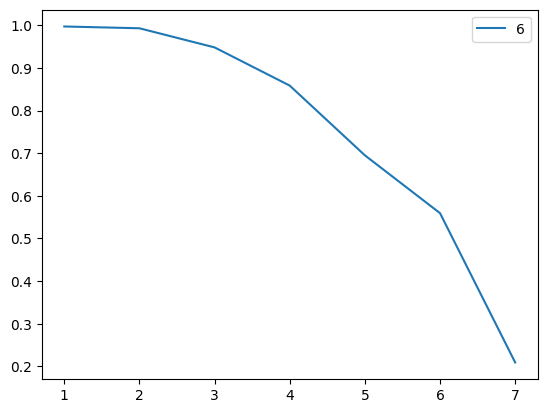

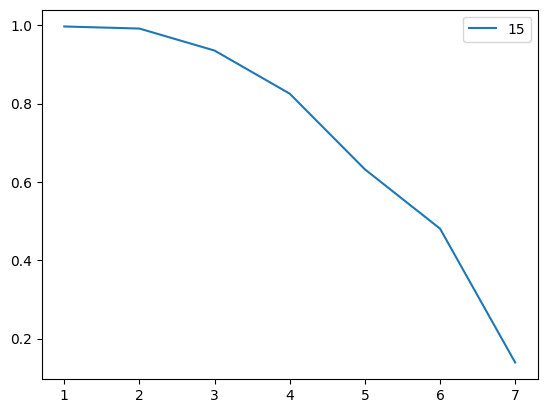

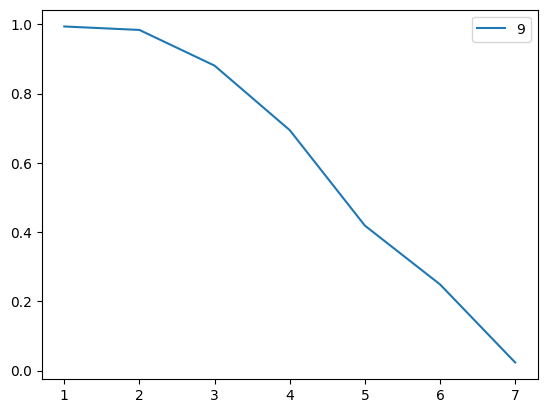

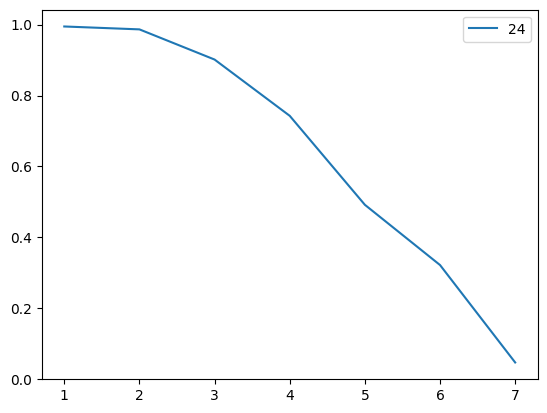

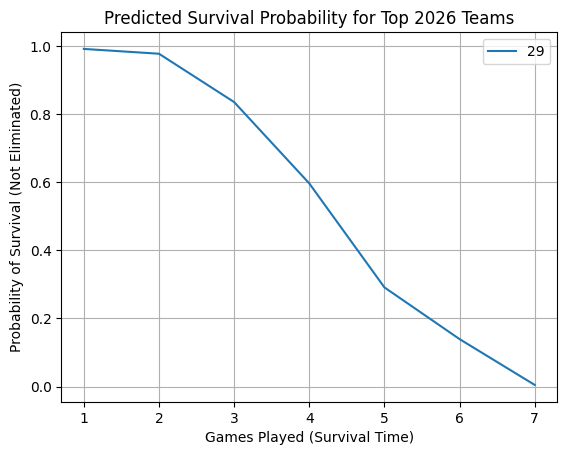


Predicted Median Survival Times for 2026 Teams (Top 10):


,0
Team,
Brazil,7.0
Germany,6.0
Croatia,5.0
Netherlands,5.0
Portugal,5.0
Turkey,5.0
Spain,5.0
France,5.0
England,5.0


In [44]:
import matplotlib.pyplot as plt

# The 'cph' model should already be fitted from the previous survival analysis section.
# If not, ensure the cell containing `cph = CoxPHFitter()` and `cph.fit(cph_df, ...)` is run.

if 'cph' not in locals():
    print("Error: CoxPHFitter model (cph) not found. Please ensure the CoxPH model fitting cell was executed.")
else:
    print("Predicting survival functions for 2026 teams...")

    # Predict the survival function for each 2026 team
    survival_functions = cph.predict_survival_function(X_2026_coxph)

    print("Survival functions predicted. Displaying for a few top teams.")

    # For better visualization, let's select a few teams to plot
    # Sort teams by their predicted median survival time to pick a diverse set
    median_survival_times_2026 = cph.predict_median(X_2026_coxph)
    median_survival_times_2026 = median_survival_times_2026.sort_values(ascending=False)

    # Select top 5 team indices for plotting
    top_team_indices_for_plot = median_survival_times_2026.head(5).index.tolist()

    plt.figure(figsize=(12, 8))
    for team_idx in top_team_indices_for_plot:
        # Get the actual team name using the index from teams_2026_historical_avg
        team_name_actual = teams_2026_historical_avg.loc[team_idx, 'Team']
        # Use the original index (team_idx) to select the correct row from X_2026_coxph for prediction
        cph.predict_survival_function(X_2026_coxph.loc[[team_idx]]).plot(label=team_name_actual)

    plt.title('Predicted Survival Probability for Top 2026 Teams')
    plt.xlabel('Games Played (Survival Time)')
    plt.ylabel('Probability of Survival (Not Eliminated)')
    plt.grid(True)
    plt.legend()
    plt.show()

    print("\nPredicted Median Survival Times for 2026 Teams (Top 10):")
    # Create a Series with team names as index for better display
    team_names_for_median = teams_2026_historical_avg.loc[median_survival_times_2026.index, 'Team']
    median_survival_times_display = pd.Series(median_survival_times_2026.values, index=team_names_for_median)
    display(median_survival_times_display.sort_values(ascending=False).head(10))

### Step 8: Compare Groups - Host vs. Non-Host Teams

Now, let's perform a similar survival analysis comparison for host teams versus non-host teams. This will help us determine if there's a 'host advantage' in terms of survival in the World Cup.

Number of Host Teams: 21
Number of Non-Host Teams: 468


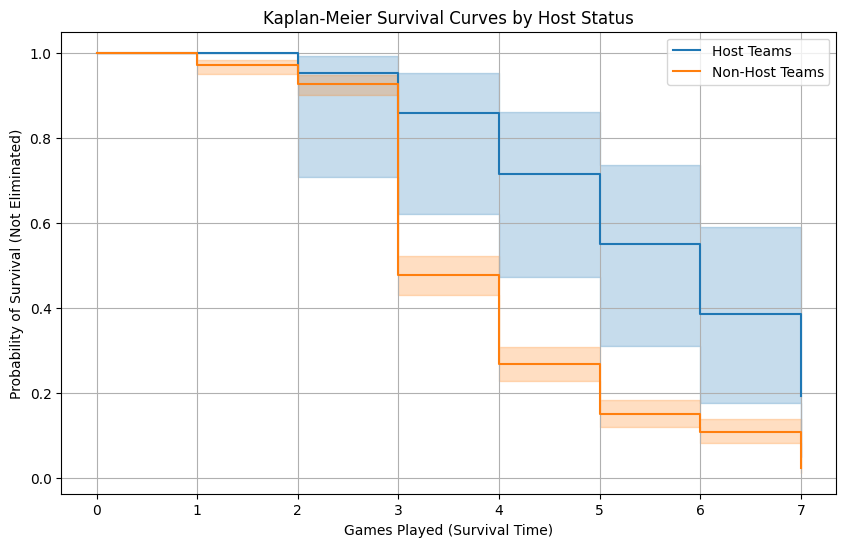


Log-Rank Test Results (Host vs. Non-Host):


In [28]:
from lifelines.statistics import logrank_test

# Create two groups: host and non-host teams
host_teams_df = combined_df[combined_df['IS_HOST'] == 1]
non_host_teams_df = combined_df[combined_df['IS_HOST'] == 0]

print(f"Number of Host Teams: {len(host_teams_df)}")
print(f"Number of Non-Host Teams: {len(non_host_teams_df)}")

# Instantiate KaplanMeierFitter for each group
kmf_host = KaplanMeierFitter()
kmf_non_host = KaplanMeierFitter()

# Fit the models
kmf_host.fit(durations=host_teams_df['Survival_Time'], event_observed=host_teams_df['Event_Indicator'], label='Host Teams')
kmf_non_host.fit(durations=non_host_teams_df['Survival_Time'], event_observed=non_host_teams_df['Event_Indicator'], label='Non-Host Teams')

# Plot the survival curves
plt.figure(figsize=(10, 6))
kmf_host.plot_survival_function()
kmf_non_host.plot_survival_function()

plt.title('Kaplan-Meier Survival Curves by Host Status')
plt.xlabel('Games Played (Survival Time)')
plt.ylabel('Probability of Survival (Not Eliminated)')
plt.legend()
plt.grid(True)
plt.show()

# Perform Log-Rank Test to compare the two groups
results_host_non_host = logrank_test(host_teams_df['Survival_Time'], non_host_teams_df['Survival_Time'],
                                     event_observed_A=host_teams_df['Event_Indicator'],
                                     event_observed_B=non_host_teams_df['Event_Indicator'])

print("\nLog-Rank Test Results (Host vs. Non-Host):")
results_host_non_host.print_summary()
